Introduction

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [17]:
# True model parameters
m_true = 2.5
b_true = -1.0

# Data points and constant measurement uncertainty
rng = np.random.default_rng(seed=42)
x = np.linspace(0, 10, 30)
sigma = np.full_like(x, 0.5)

y_true = m_true * x + b_true
y_data = y_true + rng.normal(0, sigma)

Plot Data with Error Bars 

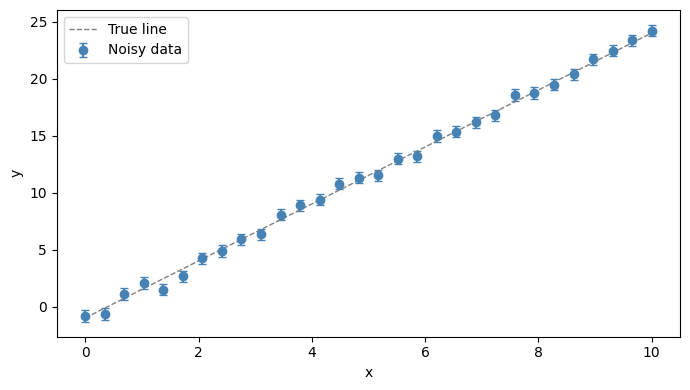

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Noisy data")

ax.plot(x, y_true, color="gray", linestyle="--",
        linewidth=1, label="True line")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

plt.tight_layout()
plt.show()

Definding the model function 

In [14]:
def line_model(x, m, b):
    """Straight line: y = m*x + b."""
    return m * x + b

In [15]:
p0 = [1.0, 0.0]  # (1) initial parameter guesses: m=1, b=0

popt, pcov = curve_fit(
    line_model,        # model function
    x,                 # independent variable
    y_data,            # measured data
    p0=p0,
    sigma=sigma,       # per-point uncertainties
    absolute_sigma=True,  # (2)
)

m_fit, b_fit     = popt
m_err, b_err     = np.sqrt(np.diag(pcov))  # (3)

print(f"m = {m_fit:.3f} ± {m_err:.3f}   (true: {m_true})")
print(f"b = {b_fit:.3f} ± {b_err:.3f}   (true: {b_true})")


m = 5.024 ± 0.031   (true: 5.0)
b = -1.112 ± 0.178   (true: -1.0)


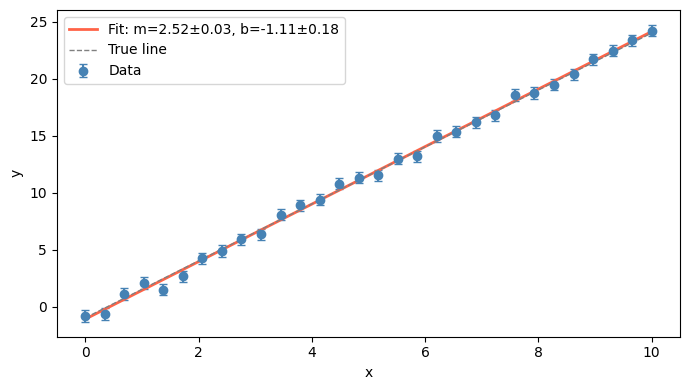

In [7]:
x_fine = np.linspace(0, 10, 200)
y_fit  = line_model(x_fine, *popt)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Data")
ax.plot(x_fine, y_fit, color="tomato", linewidth=2,
        label=f"Fit: m={m_fit:.2f}±{m_err:.2f}, b={b_fit:.2f}±{b_err:.2f}")
ax.plot(x, y_true, color="gray", linestyle="--", linewidth=1, label="True line")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()


Reduced Chi-squared 

In [8]:
residuals    = y_data - line_model(x, *popt)
chi2         = np.sum((residuals / sigma)**2)
n_dof        = len(x) - len(popt)       # degrees of freedom
chi2_reduced = chi2 / n_dof

print(f"χ² = {chi2:.2f}")
print(f"Degrees of freedom = {n_dof}")
print(f"Reduced χ² = {chi2_reduced:.2f}")


χ² = 16.88
Degrees of freedom = 28
Reduced χ² = 0.60


Excercise 

In [30]:
# True model parameters
m_true = 5.0
b_true = -1.0

# Data points and constant measurement uncertainty
rng = np.random.default_rng(seed=42)
x = np.linspace(0, 10, 30)
sigma = np.full_like(x, 0.5)

y_true = m_true * x + b_true
y_data = y_true + rng.normal(0, sigma)

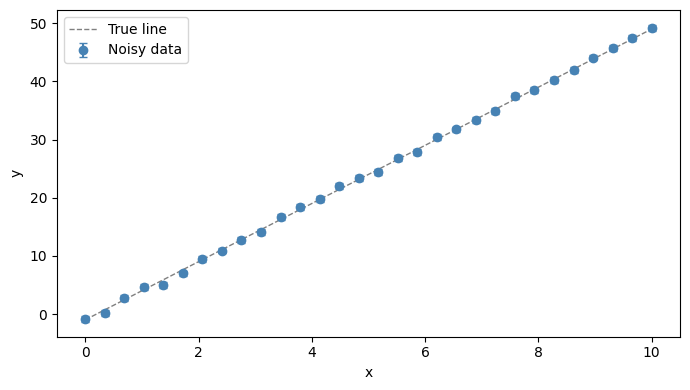

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Noisy data")

ax.plot(x, y_true, color="gray", linestyle="--",
        linewidth=1, label="True line")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

plt.tight_layout()
plt.show()

When m_true = 2.5 is changed to m_true = 5.0, the curve_fit should still find the correct slope near 5.0 even though p0 is still [1.0, 0.0]. This shows that linear fitting is not very sensitive to the initial guess.

Fit Plot Cell

In [39]:
def line_model(x, m, b):
    """Straight line: y = m*x + b."""
    return m * x + b

In [40]:
p0 = [1.0, 0.0]  # (1) initial parameter guesses: m=1, b=0

popt, pcov = curve_fit(
    line_model,        # model function
    x,                 # independent variable
    y_data,            # measured data
    p0=p0,
    sigma=sigma,       # per-point uncertainties
    absolute_sigma=True,  # (2)
)

m_fit, b_fit     = popt
m_err, b_err     = np.sqrt(np.diag(pcov))  # (3)

print(f"m = {m_fit:.3f} ± {m_err:.3f}   (true: {m_true})")
print(f"b = {b_fit:.3f} ± {b_err:.3f}   (true: {b_true})")

m = 5.024 ± 0.031   (true: 5.0)
b = -1.112 ± 0.178   (true: -1.0)


Reduced Chi-squared cell

In [41]:
residuals    = y_data - line_model(x, *popt)
chi2         = np.sum((residuals / sigma)**2)
n_dof        = len(x) - len(popt)       # degrees of freedom
chi2_reduced = chi2 / n_dof

print(f"χ² = {chi2:.2f}")
print(f"Degrees of freedom = {n_dof}")
print(f"Reduced χ² = {chi2_reduced:.2f}")

χ² = 16.88
Degrees of freedom = 28
Reduced χ² = 0.60


Exercise 2: increase sigma to 2.0. How do the parameter uncertainties change? Does the reduced chi-squared change? 

In [43]:
m_true = 2.5
b_true = -1.0

rng = np.random.default_rng(seed=42)
x = np.linspace(0, 10, 30)
sigma = np.full_like(x, 2.0)

y_true = m_true * x + b_true
y_data = y_true + rng.normal(0, sigma)

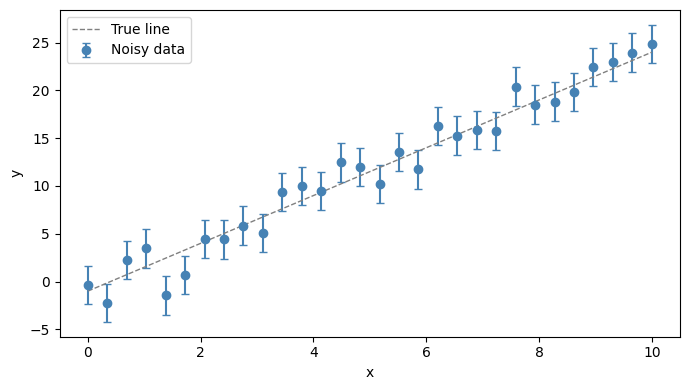

In [44]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Noisy data")

ax.plot(x, y_true, color="gray", linestyle="--",
        linewidth=1, label="True line")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

plt.tight_layout()
plt.show()

The parameter uncertainties increase because the data points are noisier. The reduced chi-squared should still be near 1 if the noise in the data matches the sigma values used in the fit.

Fit Plot Cell

In [45]:
def line_model(x, m, b):
    """Straight line: y = m*x + b."""
    return m * x + b

In [46]:
p0 = [1.0, 0.0]  # (1) initial parameter guesses: m=1, b=0

popt, pcov = curve_fit(
    line_model,        # model function
    x,                 # independent variable
    y_data,            # measured data
    p0=p0,
    sigma=sigma,       # per-point uncertainties
    absolute_sigma=True,  # (2)
)

m_fit, b_fit     = popt
m_err, b_err     = np.sqrt(np.diag(pcov))  # (3)

print(f"m = {m_fit:.3f} ± {m_err:.3f}   (true: {m_true})")
print(f"b = {b_fit:.3f} ± {b_err:.3f}   (true: {b_true})")

m = 2.596 ± 0.122   (true: 2.5)
b = -1.448 ± 0.712   (true: -1.0)


Reduced Chi-squared cell

In [47]:
residuals    = y_data - line_model(x, *popt)
chi2         = np.sum((residuals / sigma)**2)
n_dof        = len(x) - len(popt)       # degrees of freedom
chi2_reduced = chi2 / n_dof

print(f"χ² = {chi2:.2f}")
print(f"Degrees of freedom = {n_dof}")
print(f"Reduced χ² = {chi2_reduced:.2f}")

χ² = 16.88
Degrees of freedom = 28
Reduced χ² = 0.60


Summary: 

When sigma is increased to 2.0, the data points become noisier and the error bars become larger. The fitted parameter uncertainties increase because each point is less precise. The reduced chi-squared stays near the same value because the random noise was generated using the same sigma value that was used in the chi-squared calculation.

Exercise 3: Reduce the number of data points from 30 to 5. What happens to the uncertainties and the reduced chi-squared?

In [48]:
m_true = 2.5
b_true = -1.0

rng = np.random.default_rng(seed=42)
x = np.linspace(0, 10, 5)
sigma = np.full_like(x, 0.5)

y_true = m_true * x + b_true
y_data = y_true + rng.normal(0, sigma)

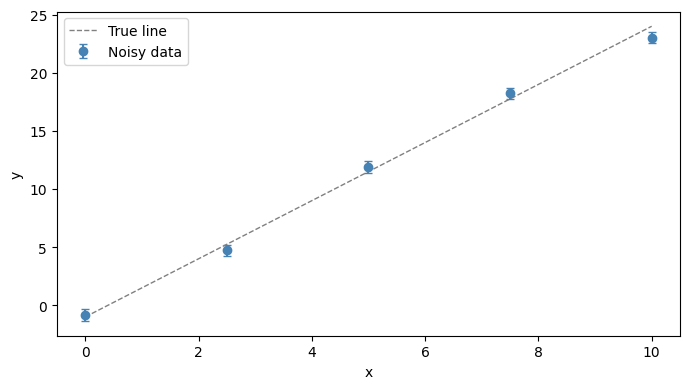

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Noisy data")

ax.plot(x, y_true, color="gray", linestyle="--",
        linewidth=1, label="True line")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

plt.tight_layout()
plt.show()

 When the number of data points is reduced from 30 to 5, the parameter uncertainties become larger because there are fewer points to constrain the line. The reduced chi-squared can fluctuate more because there are fewer degrees of freedom.

Fit Plot Cell

In [50]:
def line_model(x, m, b):
    """Straight line: y = m*x + b."""
    return m * x + b

In [51]:
p0 = [1.0, 0.0]  # (1) initial parameter guesses: m=1, b=0

popt, pcov = curve_fit(
    line_model,        # model function
    x,                 # independent variable
    y_data,            # measured data
    p0=p0,
    sigma=sigma,       # per-point uncertainties
    absolute_sigma=True,  # (2)
)

m_fit, b_fit     = popt
m_err, b_err     = np.sqrt(np.diag(pcov))  # (3)

print(f"m = {m_fit:.3f} ± {m_err:.3f}   (true: {m_true})")
print(f"b = {b_fit:.3f} ± {b_err:.3f}   (true: {b_true})")

m = 2.449 ± 0.063   (true: 2.5)
b = -0.846 ± 0.387   (true: -1.0)


Reduced Chi-squared cell

In [52]:
residuals    = y_data - line_model(x, *popt)
chi2         = np.sum((residuals / sigma)**2)
n_dof        = len(x) - len(popt)       # degrees of freedom
chi2_reduced = chi2 / n_dof

print(f"χ² = {chi2:.2f}")
print(f"Degrees of freedom = {n_dof}")
print(f"Reduced χ² = {chi2_reduced:.2f}")

χ² = 5.59
Degrees of freedom = 3
Reduced χ² = 1.86


Summary: 

When the number of data points was reduced from 30 to 5, the degrees of freedom decreased from 28 to 3. The parameter uncertainties became larger because fewer points constrain the fit. The reduced chi-squared changed more noticeably because there are fewer degrees of freedom, so the value fluctuates more.

Computing and Plotting the correlation matrix 

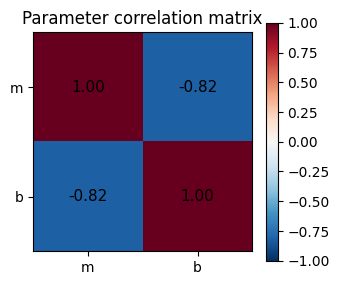

In [53]:
# Correlation matrix from covariance matrix
sigma_params = np.sqrt(np.diag(pcov))
corr = pcov / np.outer(sigma_params, sigma_params)

param_names = ["m", "b"]

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")  # (1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(param_names)))
ax.set_yticks(range(len(param_names)))
ax.set_xticklabels(param_names)
ax.set_yticklabels(param_names)

for i in range(len(param_names)):
    for j in range(len(param_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                fontsize=11, color="black")

ax.set_title("Parameter correlation matrix")
plt.tight_layout()
plt.show()


Confidence Bands 

In [54]:
n_samples = 2000
x_fine    = np.linspace(0, 10, 200)

# Sample parameter sets from the posterior distribution
param_samples = rng.multivariate_normal(popt, pcov, n_samples)  # (1)

# Evaluate model for each sample
curves = np.array([line_model(x_fine, *p) for p in param_samples])

# 68% confidence interval (1-sigma equivalent)
band_lo = np.percentile(curves, 16, axis=0)  # (2)
band_hi = np.percentile(curves, 84, axis=0)


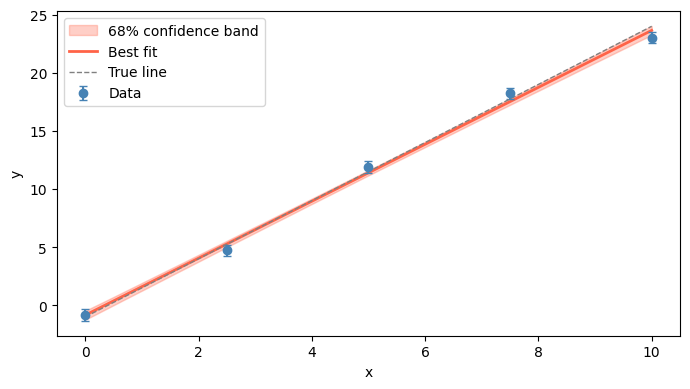

In [55]:
y_fit = line_model(x_fine, *popt)

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(x_fine, band_lo, band_hi,
                color="tomato", alpha=0.3, label="68% confidence band")
ax.plot(x_fine, y_fit, color="tomato", linewidth=2, label="Best fit")
ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Data")
ax.plot(x, y_true, color="gray", linestyle="--", linewidth=1,
        label="True line")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()


Exercise Part 1: 
Shift all x-values so the data spans x = 100 - 110 instead of 0 – 10 (add 100 to every x value). Re-run the fit. How does the correlation between m and b change in the correlation matrix? Does the confidence band become wider?


Shifted x fit results:
m = 2.4494 ± 0.0632
b = -245.7845 ± 6.6445


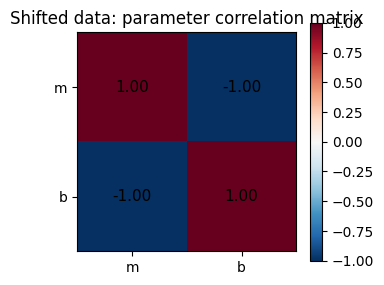

Correlation matrix:
[[ 1.         -0.99943359]
 [-0.99943359  1.        ]]


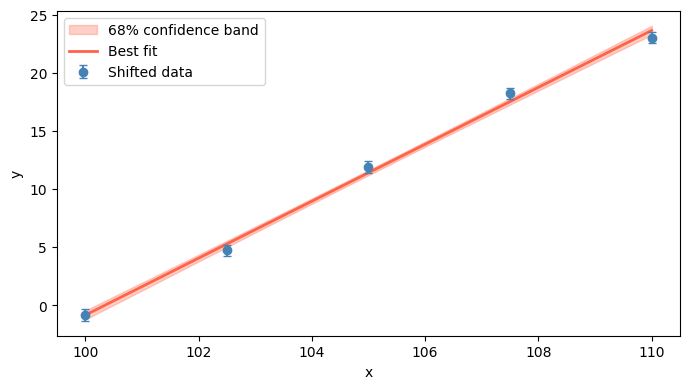

In [56]:
# ============================================================
# Part 1: Shift x-values from 0-10 to 100-110 and re-run fit
# ============================================================

# Shift x-values
x_shifted = x + 100

# Re-fit the shifted data
popt_shifted, pcov_shifted = curve_fit(
    line_model,
    x_shifted,
    y_data,
    sigma=sigma,
    absolute_sigma=True
)

# Print best-fit parameters and uncertainties
sigma_params_shifted = np.sqrt(np.diag(pcov_shifted))

print("Shifted x fit results:")
print(f"m = {popt_shifted[0]:.4f} ± {sigma_params_shifted[0]:.4f}")
print(f"b = {popt_shifted[1]:.4f} ± {sigma_params_shifted[1]:.4f}")


# ============================================================
# Correlation matrix for shifted fit
# ============================================================

corr_shifted = pcov_shifted / np.outer(sigma_params_shifted, sigma_params_shifted)

param_names = ["m", "b"]

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(corr_shifted, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(param_names)))
ax.set_yticks(range(len(param_names)))
ax.set_xticklabels(param_names)
ax.set_yticklabels(param_names)

for i in range(len(param_names)):
    for j in range(len(param_names)):
        ax.text(
            j, i,
            f"{corr_shifted[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black"
        )

ax.set_title("Shifted data: parameter correlation matrix")
plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(corr_shifted)


# ============================================================
# Confidence band for shifted fit
# ============================================================

n_samples = 2000
x_fine_shifted = np.linspace(100, 110, 200)

# Sample parameter sets from the shifted fit covariance matrix
param_samples_shifted = rng.multivariate_normal(
    popt_shifted,
    pcov_shifted,
    n_samples
)

# Evaluate model for each sampled parameter set
curves_shifted = np.array([
    line_model(x_fine_shifted, *p)
    for p in param_samples_shifted
])

# 68% confidence interval
band_lo_shifted = np.percentile(curves_shifted, 16, axis=0)
band_hi_shifted = np.percentile(curves_shifted, 84, axis=0)

# Best-fit curve
y_fit_shifted = line_model(x_fine_shifted, *popt_shifted)

# Plot shifted data with confidence band
fig, ax = plt.subplots(figsize=(7, 4))

ax.fill_between(
    x_fine_shifted,
    band_lo_shifted,
    band_hi_shifted,
    color="tomato",
    alpha=0.3,
    label="68% confidence band"
)

ax.plot(
    x_fine_shifted,
    y_fit_shifted,
    color="tomato",
    linewidth=2,
    label="Best fit"
)

ax.errorbar(
    x_shifted,
    y_data,
    yerr=sigma,
    fmt="o",
    color="steelblue",
    capsize=3,
    label="Shifted data"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()

Exercise Part 2: Reduce n_samples from 2000 to 10. What happens to the smoothness of the confidence band? How many samples are needed for a visually clean result?

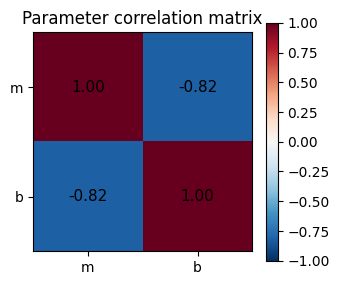

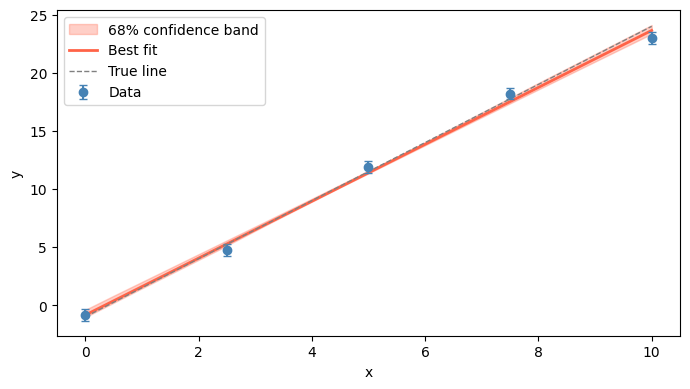

In [59]:
# Correlation matrix from covariance matrix
sigma_params = np.sqrt(np.diag(pcov))
corr = pcov / np.outer(sigma_params, sigma_params)

param_names = ["m", "b"]

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")  # (1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(param_names)))
ax.set_yticks(range(len(param_names)))
ax.set_xticklabels(param_names)
ax.set_yticklabels(param_names)

for i in range(len(param_names)):
    for j in range(len(param_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                fontsize=11, color="black")

ax.set_title("Parameter correlation matrix")
plt.tight_layout()
plt.show()

n_samples = 10
x_fine    = np.linspace(0, 10, 200)

# Sample parameter sets from the posterior distribution
param_samples = rng.multivariate_normal(popt, pcov, n_samples)  # (1)

# Evaluate model for each sample
curves = np.array([line_model(x_fine, *p) for p in param_samples])

# 68% confidence interval (1-sigma equivalent)
band_lo = np.percentile(curves, 16, axis=0)  # (2)
band_hi = np.percentile(curves, 84, axis=0)

y_fit = line_model(x_fine, *popt)

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(x_fine, band_lo, band_hi,
                color="tomato", alpha=0.3, label="68% confidence band")
ax.plot(x_fine, y_fit, color="tomato", linewidth=2, label="Best fit")
ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Data")
ax.plot(x, y_true, color="gray", linestyle="--", linewidth=1,
        label="True line")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()


Summary: 

After reducing n_samples from 2000 to 10, the confidence band still appears fairly smooth because the model is only a straight line and the uncertainties are small. However, it is less statistically reliable because the percentiles are calculated from only 10 sampled curves. If I rerun the cell, the band can change more noticeably than when using 2000 samples. A few hundred samples are usually enough for a visually clean result, while 1000–2000 samples gives a stable and smooth band.

Exercise Part 3: Change the confidence band from 68% (1σ) to 95% (2σ) by changing the percentile values. How much wider does the band become?

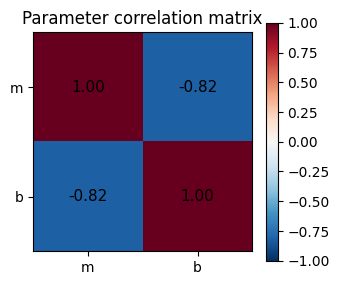

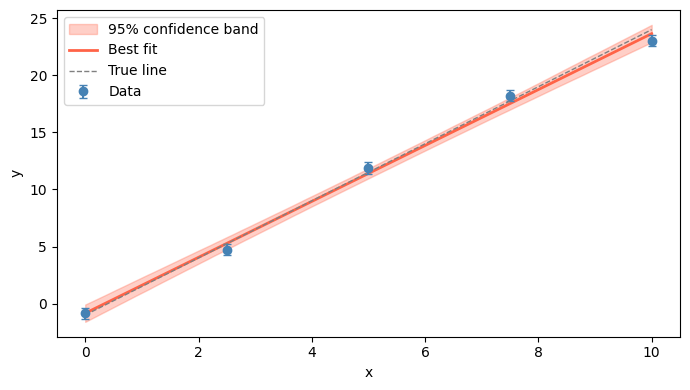

In [61]:
# Correlation matrix from covariance matrix
sigma_params = np.sqrt(np.diag(pcov))
corr = pcov / np.outer(sigma_params, sigma_params)

param_names = ["m", "b"]

fig, ax = plt.subplots(figsize=(3.5, 3))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")  # (1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(param_names)))
ax.set_yticks(range(len(param_names)))
ax.set_xticklabels(param_names)
ax.set_yticklabels(param_names)

for i in range(len(param_names)):
    for j in range(len(param_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                fontsize=11, color="black")

ax.set_title("Parameter correlation matrix")
plt.tight_layout()
plt.show()

n_samples = 2000
x_fine    = np.linspace(0, 10, 200)

# Sample parameter sets from the posterior distribution
param_samples = rng.multivariate_normal(popt, pcov, n_samples)  # (1)

# Evaluate model for each sample
curves = np.array([line_model(x_fine, *p) for p in param_samples])

# 68% confidence interval (1-sigma equivalent)
band_lo = np.percentile(curves, 2.5, axis=0)  # (2)
band_hi = np.percentile(curves, 97.5, axis=0)

y_fit = line_model(x_fine, *popt)

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(x_fine, band_lo, band_hi,
                color="tomato", alpha=0.3, label="95% confidence band")
ax.plot(x_fine, y_fit, color="tomato", linewidth=2, label="Best fit")
ax.errorbar(x, y_data, yerr=sigma, fmt="o", color="steelblue",
            capsize=3, label="Data")
ax.plot(x, y_true, color="gray", linestyle="--", linewidth=1,
        label="True line")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()



Summary: 

Changing the confidence band from 68% to 95% makes the shaded region wider because it includes more possible fitted curves. The 95% band uses the 2.5th and 97.5th percentiles, keeping the middle 95% of the sampled curves. In this plot, the band does not look dramatically wider because the linear fit has small uncertainty, but it is still wider than the 68% confidence band.

=> Fitting Scatting Data 

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sphere_form_factor(q, R):
    """
    Sphere form factor intensity P(q) for radius R.
    """
    qR = q * R

    # Avoid division by zero at qR = 0
    qR_safe = np.where(qR == 0, 1e-12, qR)

    F = 3 * (np.sin(qR_safe) - qR_safe * np.cos(qR_safe)) / (qR_safe**3)
    P = F**2

    return P


def polydisperse_sphere(q, R_mean, sigma_R, n_R=80):
    """
    Average sphere form factor over a Gaussian distribution of radii.
    """
    R_min = max(0.1, R_mean - 4 * sigma_R)
    R_max = R_mean + 4 * sigma_R

    R_values = np.linspace(R_min, R_max, n_R)

    weights = np.exp(-0.5 * ((R_values - R_mean) / sigma_R) ** 2)
    weights = weights / np.sum(weights)

    P_values = np.array([sphere_form_factor(q, R) for R in R_values])

    return np.average(P_values, axis=0, weights=weights)


def plot_form_factor(q, I, label=None):
    """
    Quick log-log plot for a form factor curve.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.loglog(q, I, label=label)
    ax.set_xlabel(r"$q$ (Å$^{-1}$)")
    ax.set_ylabel(r"$I(q)$")
    if label is not None:
        ax.legend()
    plt.tight_layout()
    plt.show()

# Hidden true parameters — do not look until after fitting!
R_true     = 47.0   # mean radius, Å
sigma_true = 7.5    # radius std dev, Å (16% relative polydispersity)
scale_true = 1.0    # overall intensity scale

q = np.logspace(-3, 0, 300)

# Generate true curve
I_true = scale_true * polydisperse_sphere(q, R_true, sigma_true)

# Add 5% multiplicative noise
rng      = np.random.default_rng(seed=7)
epsilon  = 0.05                          # fractional uncertainty
I_data   = I_true * rng.lognormal(0, epsilon, size=len(q))  # (1)
sigma_I  = I_data * epsilon              # per-point sigma = 5% of measured intensity

# Per-point sigma = 5% of measured intensity
sigma_I = I_data * epsilon


Plot with error bars 

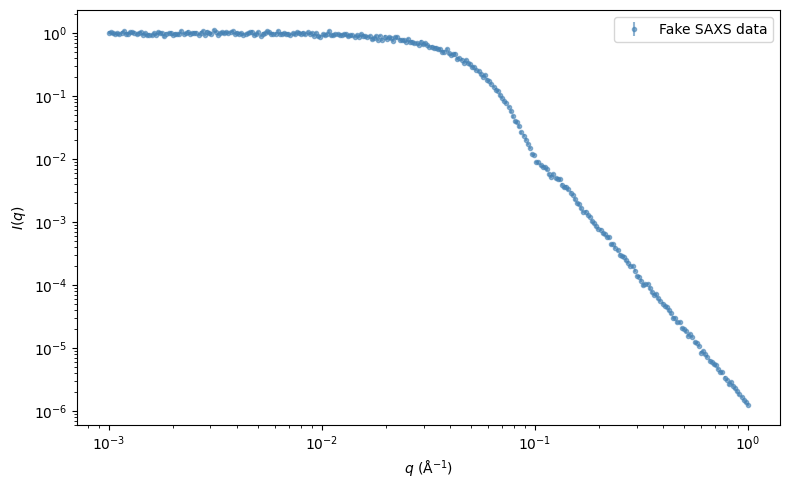

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(q, I_data, yerr=sigma_I, fmt=".", color="steelblue",
            alpha=0.6, capsize=0, label="Fake SAXS data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$q$ (Å$^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend()
plt.tight_layout()
plt.show()


Defining and Running the fit 

In [71]:
def saxs_sphere_model(q, R_mean, sigma_R, scale):
    """
    Polydisperse sphere form factor with a scale factor.

    Parameters
    ----------
    q : array-like
        Scattering vector in Å^-1.
    R_mean : float
        Mean sphere radius in Å.
    sigma_R : float
        Radius standard deviation in Å.
    scale : float
        Overall intensity scale factor.
    """
    return scale * polydisperse_sphere(q, R_mean, sigma_R)



In [72]:
p0     = [60.0, 5.0, 1.0]   # R_mean=60 Å, sigma_R=5 Å, scale=1
bounds = ([5, 0.1, 0.01], [500, 100, 100])   # (1)

popt, pcov = curve_fit(
    saxs_sphere_model,
    q,
    I_data,
    p0=p0,
    sigma=sigma_I,          # log-scale weighting
    absolute_sigma=True,
    bounds=bounds,
    maxfev=5000,             # (2)
)

R_fit, sigma_R_fit, scale_fit = popt
R_err, sigma_R_err, scale_err = np.sqrt(np.diag(pcov))

print(f"R_mean  = {R_fit:.1f} ± {R_err:.1f} Å        (true: {R_true} Å)")
print(f"sigma_R = {sigma_R_fit:.1f} ± {sigma_R_err:.1f} Å   (true: {sigma_true} Å)")
print(f"scale   = {scale_fit:.3f} ± {scale_err:.3f}     (true: {scale_true})")


R_mean  = 47.1 ± 0.1 Å        (true: 47.0 Å)
sigma_R = 7.7 ± 0.1 Å   (true: 7.5 Å)
scale   = 0.988 ± 0.004     (true: 1.0)


Reduced chi-squared

In [73]:
residuals    = I_data - saxs_sphere_model(q, *popt)
chi2         = np.sum((residuals / sigma_I)**2)
n_dof        = len(q) - len(popt)
chi2_reduced = chi2 / n_dof

print(f"Reduced χ² = {chi2_reduced:.3f}")


Reduced χ² = 0.849


Plotting the fit and confidence band 

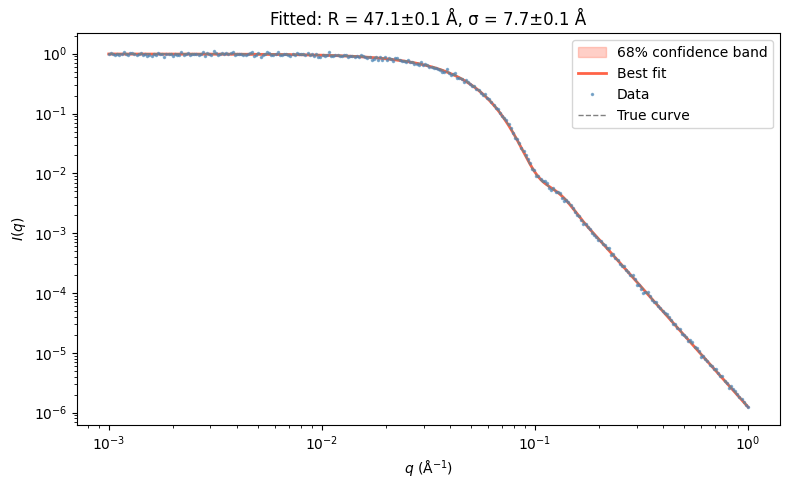

In [75]:
# Confidence band via Monte Carlo sampling
n_samples     = 1000
param_samples = rng.multivariate_normal(popt, pcov, n_samples)
curves        = np.array([saxs_sphere_model(q, *p) for p in param_samples
                           if p[0] > 0 and p[1] > 0 and p[2] > 0])  # (1)
band_lo = np.percentile(curves, 16, axis=0)
band_hi = np.percentile(curves, 84, axis=0)

I_fit = saxs_sphere_model(q, *popt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(q, band_lo, band_hi, color="tomato", alpha=0.3,
                label="68% confidence band")
ax.loglog(q, I_fit,   color="tomato",   linewidth=2, label="Best fit")
ax.loglog(q, I_data,  color="steelblue", linewidth=0,
          marker=".", markersize=3, alpha=0.6, label="Data")
ax.loglog(q, I_true,  color="gray",    linestyle="--", linewidth=1,
          label="True curve")
ax.set_xlabel(r"$q$ (Å$^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend()
ax.set_title(f"Fitted: R = {R_fit:.1f}±{R_err:.1f} Å, "
             f"σ = {sigma_R_fit:.1f}±{sigma_R_err:.1f} Å")
plt.tight_layout()
plt.show()


Correlation Matrix

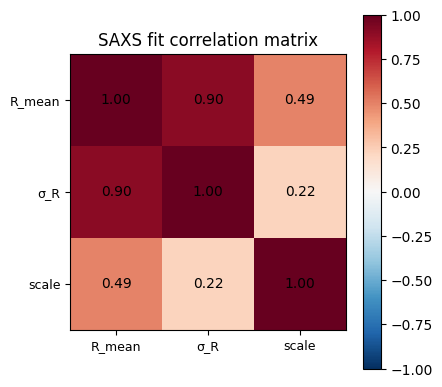

In [76]:
param_names  = ["R_mean", "σ_R", "scale"]
sigma_params = np.sqrt(np.diag(pcov))
corr         = pcov / np.outer(sigma_params, sigma_params)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(param_names, fontsize=9)
ax.set_yticklabels(param_names, fontsize=9)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("SAXS fit correlation matrix")
plt.tight_layout()
plt.show()


Summary: 

The SAXS fit successfully recovered the hidden parameters. The best-fit curve closely overlaps the fake data and the true curve, and the fitted radius and polydispersity are close to the true values. The reduced uncertainty band is narrow, showing that the fit is well constrained. The correlation matrix shows a strong positive correlation between R_mean and sigma_R around 0.90, meaning that the mean radius and polydispersity are not completely independent. This makes sense because changing the radius and changing the width of the radius distribution can both affect the position and smoothing of the SAXS oscillations.

Exercise 1: Change the initial guess p0 = [60.0, 5.0, 1.0] to a value far from the truth, say p0 = [200.0, 20.0, 1.0]. Does curve_fit still converge to the correct answer? What happens if you try p0 = [5.0, 0.5, 1.0]?

In [78]:
p0     = [60.0, 5.0, 1.0]   # R_mean=60 Å, sigma_R=5 Å, scale=1
bounds = ([5, 0.1, 0.01], [500, 100, 100])   # (1)

popt, pcov = curve_fit(
    saxs_sphere_model,
    q,
    I_data,
    p0=p0,
    sigma=sigma_I,          # log-scale weighting
    absolute_sigma=True,
    bounds=bounds,
    maxfev=5000,             # (2)
)

R_fit, sigma_R_fit, scale_fit = popt
R_err, sigma_R_err, scale_err = np.sqrt(np.diag(pcov))

print(f"R_mean  = {R_fit:.1f} ± {R_err:.1f} Å        (true: {R_true} Å)")
print(f"sigma_R = {sigma_R_fit:.1f} ± {sigma_R_err:.1f} Å   (true: {sigma_true} Å)")
print(f"scale   = {scale_fit:.3f} ± {scale_err:.3f}     (true: {scale_true})")


R_mean  = 47.1 ± 0.1 Å        (true: 47.0 Å)
sigma_R = 7.7 ± 0.1 Å   (true: 7.5 Å)
scale   = 0.988 ± 0.004     (true: 1.0)


In [79]:
p0     = [200.0, 20.0, 1.0]   # R_mean=60 Å, sigma_R=5 Å, scale=1
bounds = ([5, 0.1, 0.01], [500, 100, 100])   # (1)

popt, pcov = curve_fit(
    saxs_sphere_model,
    q,
    I_data,
    p0=p0,
    sigma=sigma_I,          # log-scale weighting
    absolute_sigma=True,
    bounds=bounds,
    maxfev=5000,             # (2)
)

R_fit, sigma_R_fit, scale_fit = popt
R_err, sigma_R_err, scale_err = np.sqrt(np.diag(pcov))

print(f"R_mean  = {R_fit:.1f} ± {R_err:.1f} Å        (true: {R_true} Å)")
print(f"sigma_R = {sigma_R_fit:.1f} ± {sigma_R_err:.1f} Å   (true: {sigma_true} Å)")
print(f"scale   = {scale_fit:.3f} ± {scale_err:.3f}     (true: {scale_true})")


R_mean  = 47.1 ± 0.1 Å        (true: 47.0 Å)
sigma_R = 7.7 ± 0.1 Å   (true: 7.5 Å)
scale   = 0.988 ± 0.004     (true: 1.0)


In [80]:
p0     = [5.0, 0.5, 1.0]   # R_mean=60 Å, sigma_R=5 Å, scale=1
bounds = ([5, 0.1, 0.01], [500, 100, 100])   # (1)

popt, pcov = curve_fit(
    saxs_sphere_model,
    q,
    I_data,
    p0=p0,
    sigma=sigma_I,          # log-scale weighting
    absolute_sigma=True,
    bounds=bounds,
    maxfev=5000,             # (2)
)

R_fit, sigma_R_fit, scale_fit = popt
R_err, sigma_R_err, scale_err = np.sqrt(np.diag(pcov))

print(f"R_mean  = {R_fit:.1f} ± {R_err:.1f} Å        (true: {R_true} Å)")
print(f"sigma_R = {sigma_R_fit:.1f} ± {sigma_R_err:.1f} Å   (true: {sigma_true} Å)")
print(f"scale   = {scale_fit:.3f} ± {scale_err:.3f}     (true: {scale_true})")


R_mean  = 47.1 ± 0.1 Å        (true: 47.0 Å)
sigma_R = 7.7 ± 0.1 Å   (true: 7.5 Å)
scale   = 0.988 ± 0.004     (true: 1.0)


Summary: 

Different initial guesses can converge to the same correct answer if the fit is stable and the data strongly constrains the parameters. In my case, even guesses that were far from the true values still converged to the same final fit, which suggests the optimization problem was well-behaved. However, this is not guaranteed for every nonlinear model. If the starting guess is too poor, curve_fit can sometimes get stuck in a local minimum or fail to converge. 

I changed the initial guess to p0 = [200.0, 20.0, 1.0] and then to p0 = [5.0, 0.5, 1.0]. In my run, both fits still converged to the same fitted values as the original fit: R_mean ≈ 47.1 Å, sigma_R ≈ 7.7 Å, and scale ≈ 0.988. This suggests that this particular fake SAXS dataset has a well-defined minimum and the optimizer was able to recover the correct solution even from poor starting guesses. However, the answer key’s warning still applies: for nonlinear models, poor initial guesses can sometimes cause the optimizer to get stuck or fail, so reasonable initial guesses are still important.

Exercise 2: Increase the noise level from epsilon = 0.05 to epsilon = 0.30 (30% noise). How do the parameter uncertainties change? Does the reduced chi-squared remain close to 1.0?

Exercise 3: Set sigma_true = 1.0 Å (nearly monodisperse). What happens to the oscillations in the fake data? Is curve_fit able to reliably recover sigma_R? Look at the parameter correlation matrix — what does it tell you about fitting polydispersity from data without visible oscillations?


Exercise 4: Replace sigma_I = I_data * epsilon with sigma_I = np.full_like(I_data, epsilon) (constant, unweighted errors). Re-run the fit. How do the recovered parameters change? Does the fit still describe the oscillations at large q?